# 07 — Budget Optimization & Scenario Analysis

## Objective
Using the Ridge regression model fitted in **Notebook 06**, this notebook:
1. **Reconstructs response functions** from NB06's saturation curves (nonlinear)
2. **Optimizes budget allocation** — finds the spend mix that maximizes total media-driven revenue
3. **Runs scenario analysis** — what happens with 10–15% budget cuts? Budget increases?
4. **Produces executive recommendations** — actionable reallocation guidance

## Relationship to Notebook 06
- **NB06**: Fits Ridge models, validates (LOOCV, bootstrap), estimates channel effectiveness & ROAS
- **NB07 (this)**: Takes NB06's outputs and answers *"what should we do?"*

## Inputs from NB06
| File | Contents |
|------|----------|
| `media_effectiveness_results.csv` | Marginal effects, ROAS, contribution per channel |
| `saturation_curves.csv` | Spend → incremental revenue curves (10 points/channel) |
| `causal_model_params.json` | Decay rates, saturation params, R², feature names |
| `robustness_summary.csv` | Which channels pass stability checks |

---

## Section 0 — Setup & Key Findings Recap

In [1]:
# ---------- Imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
from datetime import datetime
from scipy.interpolate import interp1d
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ---------- Plot settings ----------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette('husl')

# ---------- Paths ----------
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path = project_root / 'reports' / 'figures'
reports_path = project_root / 'reports'

figures_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print(f'Project root : {project_root}')
print(f'Processed    : {processed_path}')

Project root : /Users/tuta/Desktop/busa693-clubpiscine
Processed    : /Users/tuta/Desktop/busa693-clubpiscine/data/processed


In [2]:
# ---------- Load NB06 outputs ----------

# 1. Effectiveness results
eff_df = pd.read_csv(processed_path / 'media_effectiveness_results.csv')
print(f'Loaded media_effectiveness_results.csv: {eff_df.shape}')

# 2. Saturation curves (10 points per channel)
sat_curves_df = pd.read_csv(processed_path / 'saturation_curves.csv')
print(f'Loaded saturation_curves.csv: {sat_curves_df.shape}')

# 3. Model parameters
with open(processed_path / 'causal_model_params.json') as f:
    model_params = json.load(f)
print(f'Loaded causal_model_params.json')

# 4. Robustness summary
robust_df = pd.read_csv(processed_path / 'robustness_summary.csv')
print(f'Loaded robustness_summary.csv: {robust_df.shape}')

# 5. Raw data for spend context
df = pd.read_csv(processed_path / 'sales_spend_weather.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded sales_spend_weather.csv: {df.shape}')

Loaded media_effectiveness_results.csv: (49, 10)
Loaded saturation_curves.csv: (70, 4)
Loaded causal_model_params.json
Loaded robustness_summary.csv: (7, 5)
Loaded sales_spend_weather.csv: (36, 43)


In [3]:
# ---------- Channel setup ----------

CHANNELS = model_params['media_channels']

CHANNEL_LABELS = {
    'television':          'Television',
    'radio':               'Radio',
    'panneaux':            'Panneaux (Outdoor)',
    'social_media':        'Social Media',
    'preroll':             'Preroll (Video)',
    'banniere_web':        'Web Banners',
    'circulaire_digitale': 'Digital Flyers',
}

SPEND_COLS = {ch: f'spend_{ch}' for ch in CHANNELS}

# Current average monthly spend per channel
CURRENT_SPEND = {ch: df[SPEND_COLS[ch]].mean() for ch in CHANNELS}
TOTAL_MONTHLY_BUDGET = sum(CURRENT_SPEND.values())

# Effectiveness for total revenue only
eff_total = eff_df[eff_df['product'] == 'Total Revenue'].set_index('channel')

# Total revenue stats
total_revenue_3y = df['total_all_revenue'].sum()
avg_monthly_revenue = df['total_all_revenue'].mean()
total_spend_3y = sum(df[SPEND_COLS[ch]].sum() for ch in CHANNELS)

print('=== NB06 Key Findings (Recap) ===')
print(f'Model R\u00b2 (Total Revenue):      {model_params["ridge_r2"]["Total Revenue"]:.3f}')
print(f'Model LOOCV R\u00b2:                {model_params["ridge_r2_cv"]["Total Revenue"]:.3f}')
print(f'Observations:                  {len(df)} months (FY2023-FY2025)')
print(f'Total Revenue (3Y):            ${total_revenue_3y:,.0f}')
print(f'Total Media Spend (3Y):        ${total_spend_3y:,.0f}')
print(f'Avg Monthly Budget:            ${TOTAL_MONTHLY_BUDGET:,.0f}')
print()
print('Channel ROAS (from NB06):')
for ch in CHANNELS:
    roas = eff_total.loc[ch, 'roas']
    spend = CURRENT_SPEND[ch]
    ci_lo = eff_total.loc[ch, 'marginal_ci_lo']
    ci_hi = eff_total.loc[ch, 'marginal_ci_hi']
    sig = 'sig' if ci_lo > 0 else '   '
    print(f'  {CHANNEL_LABELS[ch]:25s}  ROAS={roas:>8.1f}  spend=${spend:>8,.0f}/mo  CI=[{ci_lo:>7,.0f}, {ci_hi:>7,.0f}]  {sig}')

=== NB06 Key Findings (Recap) ===
Model R² (Total Revenue):      0.916
Model LOOCV R²:                0.862
Observations:                  36 months (FY2023-FY2025)
Total Revenue (3Y):            $512,411,602
Total Media Spend (3Y):        $10,257,505
Avg Monthly Budget:            $284,931

Channel ROAS (from NB06):
  Television                 ROAS=    16.8  spend=$ 109,693/mo  CI=[  9,205,  23,997]  sig
  Radio                      ROAS=    23.3  spend=$  60,202/mo  CI=[ 10,054,  36,154]  sig
  Panneaux (Outdoor)         ROAS=    88.1  spend=$   8,125/mo  CI=[ -7,949, 189,426]     
  Social Media               ROAS=   143.1  spend=$  22,984/mo  CI=[ 49,287, 216,869]  sig
  Preroll (Video)            ROAS=   153.4  spend=$  22,574/mo  CI=[119,786, 170,042]  sig
  Web Banners                ROAS=    29.1  spend=$  48,949/mo  CI=[  2,029,  66,700]  sig
  Digital Flyers             ROAS=    89.2  spend=$  12,404/mo  CI=[ 27,173, 160,539]  sig


In [4]:
# ===================================================================
# CLIENT CONSTRAINTS — MODEL COVERAGE ASSESSMENT
# ===================================================================
#
# The client provided 18 business constraints. Below we map the RELEVANT
# ones to how the model handles them. Constraints about GRP/PEB comparability
# (2-5) are excluded — our model uses $ spend, not GRPs or impressions.
#
# STATUS KEY:
#   CAPTURED  = accounted for in the Ridge model features
#   PARTIAL   = partially captured but with limitations
#   LIMITATION = not modeled, affects interpretation of results
#   OPTIMIZER = should constrain the budget optimization
# -------------------------------------------------------------------

CLIENT_CONSTRAINTS = {
    # --- CAPTURED or PARTIALLY CAPTURED ---
    17: {
        'name': 'Weather and Regional Climate Variability',
        'status': 'PARTIAL',
        'detail': ('Model includes weather deviations (sunshine hours, precipitation, '
                   'days above 25C) as controls. However, these are province-wide '
                   'averages — regional variation within Quebec is not captured.'),
    },
    6: {
        'name': 'Impression Quality Variability',
        'status': 'PARTIAL',
        'detail': ('Different channels have separate coefficients, so a $ spent on '
                   'Preroll (video) is valued differently than a $ on Web Banners. '
                   'This implicitly captures quality differences, but not explicitly.'),
    },
    8: {
        'name': 'Precision and Scale Limitations of Digital',
        'status': 'PARTIAL',
        'detail': ('Saturation curves capture diminishing returns per channel, '
                   'reflecting the "you get what you pay for" dynamic in digital.'),
    },

    # --- LIMITATIONS (affect interpretation, cannot be modeled) ---
    1: {
        'name': 'Structural Media Mix Evolution (Traditional to Digital)',
        'status': 'LIMITATION',
        'detail': ('No trend variable in the model. The deliberate shift from '
                   'traditional to digital introduces non-stationarity. Historical '
                   'media efficiency may not fully apply to later periods.'),
    },
    7: {
        'name': 'Traditional Media Spill Effects',
        'status': 'LIMITATION',
        'detail': ('TV and Radio generate reach beyond the target audience (spill). '
                   'The model may UNDERVALUE traditional media because spill-driven '
                   'brand salience is not separately captured.'),
    },
    9: {
        'name': 'Creative Execution as Unmodeled Variable',
        'status': 'LIMITATION',
        'detail': ('Model captures media exposure, not creative quality. Observed '
                   'performance differences may reflect creative strength rather '
                   'than media efficiency alone.'),
    },
    11: {
        'name': 'Brand Positioning and Premium Environment Choices',
        'status': 'LIMITATION',
        'detail': ('Premium contexts (TV, quality video) were chosen to elevate brand '
                   'perception. These may appear less cost-efficient in short-term ROAS '
                   'but serve long-term brand building not captured by the model.'),
    },
    14: {
        'name': 'Unobserved Local Store Marketing Activity',
        'status': 'LIMITATION',
        'detail': ('Local store marketing initiatives are not in the dataset. '
                   'These may inflate or distort observed media effects.'),
    },
    16: {
        'name': 'Inventory, Installation and Capacity Constraints',
        'status': 'LIMITATION',
        'detail': ('Media-driven demand may not convert to sales if supply is '
                   'constrained. The model may underestimate true media effectiveness '
                   'during peak season.'),
    },
    18: {
        'name': 'Competitive Pressure as Unobserved Influence',
        'status': 'LIMITATION',
        'detail': ('Competitor activity (Trevi, Sima, big-box retailers) is not '
                   'modeled. Demand shifts from competitive actions are attributed '
                   'to the intercept/residual.'),
    },

    # --- OPTIMIZER CONSTRAINTS (should influence budget recommendations) ---
    10: {
        'name': 'Production vs Media Investment Ratio (80/20)',
        'status': 'OPTIMIZER',
        'detail': ('Club Piscine targets ~85% media / 15% production. Production '
                   'investment affects effectiveness but is not in the model. '
                   'Reallocations must account for associated production costs.'),
    },
    12: {
        'name': 'Strategic Category Visibility Allocation',
        'status': 'OPTIMIZER',
        'detail': ('Media visibility was intentionally split: ~40% furniture/gazebos, '
                   '~30% pools, ~20% spas, ~5% BBQ, ~5% other. The optimizer should '
                   'not violate this strategic intent.'),
    },
    13: {
        'name': 'Furniture as Growth-Led Strategic Focus',
        'status': 'OPTIMIZER',
        'detail': ('Club Piscine is already top-of-mind for pools/spas (diminishing '
                   'returns). Media was deliberately shifted to furniture (growth '
                   'category). Pure ROAS-based optimization would miss this.'),
    },
    15: {
        'name': 'Deliberate Overinvestment in Fitness',
        'status': 'OPTIMIZER',
        'detail': ('Fitness is deliberately overinvested to maintain store traffic '
                   'and brand presence during off-season. The model shows poor fitness '
                   'R2 (0.42) — this is expected, not a model failure.'),
    },
}

# Print summary
print('CLIENT CONSTRAINTS — MODEL COVERAGE')
print('=' * 90)
for num, c in sorted(CLIENT_CONSTRAINTS.items()):
    print(f'  #{num:>2d}  [{c["status"]:>10s}]  {c["name"]}')
print()

# Count by status
from collections import Counter
status_counts = Counter(c['status'] for c in CLIENT_CONSTRAINTS.values())
for status, count in sorted(status_counts.items()):
    print(f'  {status:>10s}: {count} constraints')
print()
print('NOTE: Constraints 2-5 (GRP/PEB comparability, impressions) are excluded —')
print('      our model uses dollar spend, not GRPs or impressions.')

CLIENT CONSTRAINTS — MODEL COVERAGE
  # 1  [LIMITATION]  Structural Media Mix Evolution (Traditional to Digital)
  # 6  [   PARTIAL]  Impression Quality Variability
  # 7  [LIMITATION]  Traditional Media Spill Effects
  # 8  [   PARTIAL]  Precision and Scale Limitations of Digital
  # 9  [LIMITATION]  Creative Execution as Unmodeled Variable
  #10  [ OPTIMIZER]  Production vs Media Investment Ratio (80/20)
  #11  [LIMITATION]  Brand Positioning and Premium Environment Choices
  #12  [ OPTIMIZER]  Strategic Category Visibility Allocation
  #13  [ OPTIMIZER]  Furniture as Growth-Led Strategic Focus
  #14  [LIMITATION]  Unobserved Local Store Marketing Activity
  #15  [ OPTIMIZER]  Deliberate Overinvestment in Fitness
  #16  [LIMITATION]  Inventory, Installation and Capacity Constraints
  #17  [   PARTIAL]  Weather and Regional Climate Variability
  #18  [LIMITATION]  Competitive Pressure as Unobserved Influence

  LIMITATION: 7 constraints
   OPTIMIZER: 4 constraints
     PARTIAL: 3 cons

---
## Full Business Constraints & Media Strategy Reference

This section documents **all 18 client-provided business constraints** and the **media strategy narrative** verbatim, followed by a model-relevance classification.

---

### Client Business Constraints (Verbatim)

**1. Structural Media Mix Evolution**
Year over year, Club Piscine has deliberately shifted a portion of its investments from traditional media toward digital media in order to reach a long-term equilibrium of approximately 50% traditional and 50% digital. This structural evolution introduces non-stationarity into the data, meaning historical media efficiency relationships may not fully apply to later periods.

**2. GRP/PEB Market Comparability**
Media buying units such as GRPs (PEBs) are not directly comparable or interchangeable across markets. A GRP delivered in Montreal against Adults 25–54 does not represent the same reach, frequency, audience composition or cost dynamics as a GRP delivered in Quebec City or other regional markets, even when the target definition appears identical.

**3. GRP/PEB Target Definition Differences**
GRPs are not interchangeable across target definitions within the same market. A GRP against Adults 18+ does not carry the same meaning or impact as a GRP against Adults 25–54 due to differences in audience size, media consumption habits and availability.

**4. Language-Based GRP Differences**
Language further limits comparability. A GRP delivered in French in Montreal is not equivalent to a GRP delivered in English in the same market, even when age targets are identical. Media supply, audience concentration and pricing structures differ materially by language.

**5. Impressions as an Imperfect Common Denominator**
Impressions are used as the primary common denominator across media channels; however, traditional media impressions are derived from panel-based surveys and statistical extrapolations, while out-of-home impressions are estimated using traffic and mobility data. Digital impressions are measured more precisely, but methodologies vary significantly by platform, limiting strict cross-channel comparability.

**6. Impression Quality Variability**
Not all impressions are equal in qualitative impact. A premium video pre-roll impression delivers significantly more attention and brand impact than a standard display banner impression. As a result, channels generating higher impression volumes should not automatically be interpreted as more effective.

**7. Traditional Media Spill Effects**
Traditional media targeting relies primarily on demographic criteria and inherently generates spill, meaning impressions are delivered beyond the intended target audience. When spill is considered, mass media channels often prove highly cost-effective at building reach and brand salience.

**8. Precision and Scale Limitations of Digital Media**
Digital media allows for highly precise targeting based on interests, behaviors or purchase intent, but impressions are delivered one user at a time and generate no spill. Digital reach is therefore constrained by budget and bid dynamics, following a "you get what you pay for" model.

**9. Creative Execution as an Unmodeled Variable**
The MMM captures media exposure and visibility but does not directly measure creative quality. Differences in observed performance may reflect creative execution strength rather than media efficiency alone, which limits purely media-driven interpretations.

**10. Production vs Media Investment Ratio**
Across its media initiatives, Club Piscine intentionally targets an approximate 80/20 split between media investment and production costs, with most campaigns closer to 85% media and 15% production. Production investment materially influences effectiveness but is not directly observed in the MMM.

**11. Brand Positioning and Premium Environment Choices**
One of the key strategic objectives during the current year was to elevate the perceived quality and elegance of the Club Piscine brand. This objective influenced both creative choices and media environments, sometimes favoring premium contexts that may appear less cost efficient from a short-term performance perspective.

**12. Strategic Category Visibility Allocation**
Media visibility was intentionally distributed across product categories in a non-revenue-proportional manner. Approximately 40% of visibility was allocated to outdoor furniture and gazebos, 30% to pools (above-ground and in-ground), 20% to spas, 5% to barbecues and 5% to other categories.

**13. Furniture as a Growth-Led Strategic Focus**
Research and historical performance have demonstrated that Club Piscine is already perceived as a must-consider brand for pool and spa purchase intentions, leading to diminishing marginal returns from incremental investment in these categories. Media efforts were therefore deliberately shifted toward furniture, which represents both the strongest growth opportunity and the most competitive category.

**14. Unobserved Local Store Marketing Activity**
Many stores execute additional local marketing initiatives that are not fully captured in the centralized dataset used for the MMM. These initiatives can materially influence local performance.

**15. Deliberate Overinvestment in the Fitness Category**
Despite declining fitness sales in recent years, Club Piscine has made a deliberate decision to overinvest in the fitness category relative to its direct revenue contribution in order to maintain store traffic and brand presence during the off-season.

**16. Inventory, Installation and Capacity Constraints**
Sales performance is partially constrained by product availability, installation capacity and delivery lead times, particularly for pools and spas. Media-driven demand may not always translate into incremental sales if operational capacity is saturated.

**17. Weather and Regional Climate Variability**
Weather is a major exogenous driver of demand, store traffic and conversion. Club Piscine operates across the entire province of Quebec, where regional climates can differ significantly at any given time. Campaigns are planned centrally and optimized based on majority conditions rather than regional exceptions, which can create temporary mismatches between messaging and local readiness.

**18. Competitive Pressure as an Unobserved Influence**
Competitive pressure from both direct competitors such as Trévi and Sima, and indirect competitors such as big-box retailers and home improvement centers, materially influences demand dynamics. While this competitive activity is not fully tracked or modeled, it affects category interest, timing and observed performance, and should be considered an unobserved external influence on MMM outputs.

---

### Media Strategy Narrative (Verbatim)

Club Piscine operates in a highly seasonal category, where the majority of demand is concentrated within a relatively short period of the year. Approximately 85% of media investments are deployed between March and September, a timeframe during which purchase intent and demand peak, particularly around May. Because Club Piscine is largely absent from the advertising landscape for several months during the off-season, rebuilding momentum at the start of each season is structurally more challenging. Early-season media activity therefore plays a critical role in re-establishing brand presence, reactivating consumer memory and restarting demand dynamics that have gone dormant during the winter months.

Consumer behavior evolves significantly throughout the season. From March through April and May, extending into mid-June, consumers are primarily in an inspiration and planning mindset. During this phase, they are exploring ideas, visualizing their outdoor space and evaluating options, often well ahead of a final purchase decision. From mid-June through September, behavior shifts toward a more transactional mindset, where consumers are increasingly focused on promotions, availability and deals. This shift in intent materially affects media responsiveness and the relative contribution of brand versus performance-driven tactics over time.

Purchase decisions—especially for high-involvement products such as pools, spas and outdoor furniture—are influenced several weeks prior to the actual transaction. For this reason, Club Piscine intentionally brings forward its media investments relative to the natural seasonality of the category. Media activity starts earlier in order to generate momentum, establish brand presence in consumers' minds, and maximize the effectiveness of more transactional levers once demand reaches its peak. This approach results in meaningful lagged and carryover effects, particularly at the beginning of the season, which should be explicitly accounted for in the model.

The media strategy is built around a balanced mix, with approximately 50% of the budget allocated to traditional media and 50% to digital media. Each channel plays a distinct and complementary role within the consumer journey, and overall performance is driven by cumulative effects, sequencing and cross-media synergies rather than by isolated channel contributions.

**Television** is used as a foundational medium at the start of the season. Its primary role is to rebuild brand salience after a period of inactivity and to create strong emotional associations by projecting consumers into summer moments and an outdoor lifestyle. Television is particularly influential during the inspiration-driven phase of the season, when consumers are forming preferences and mental availability. It rarely generates immediate sales effects; instead, its impact materializes over time through increased consideration, branded search, store visits and improved efficiency across all other media tactics. Television creates a significant halo effect, amplifying the performance of radio, digital video, display, paid search, performance media and the digital flyer. We focus our presence in top performing shows in March, April and May to maximize reach, while taking advantage of the favorable television viewership habits in the Québec province compared to all other Canadian markets. As the season progresses (June, July, August), television viewership declines, and consumers become more deal-oriented. So we adapt the strategy. The messaging is delivered mainly in local news, weather and other commodity programming and becomes more commercial, supporting promotions and clearance events, while still benefiting from substantial residual effects. Television activity is national, with higher weight in the Montreal, Quebec City and Gatineau markets, and is delivered exclusively in French.

**Radio** functions as a more tactical mass medium and takes over as television viewership declines, particularly from mid-May onward. It is used both to sustain brand presence and to stimulate short-term sales, with effects that tend to be more immediate than television. Radio becomes increasingly important as consumers move into a deal-seeking mindset later in the season. It plays a critical role in regional markets and is one of the primary drivers of localized demand. The language mix varies by market: Montreal uses a combination of French and English stations, all other Quebec markets are French only, and the Ottawa market is English only. From April through July, Club Piscine runs short, three-day promotional events that are supported by live in-store radio remotes. These activations create sharp, time-bound increases in traffic and sales and should be treated as distinct tactical bursts within the model.

**Digital out-of-home (DOOH)** consists exclusively of digital billboards purchased using dayparting strategies. These placements are specifically selected to reach consumers during their commute home, with a strong emphasis on return-facing panels. Multiple creative executions can rotate in loop, allowing messaging to adapt to the time of day, promotional calendar or product category. Digital out-of-home plays a dual role: early in the season it reinforces inspiration and brand presence, while later in the season it supports promotional messaging and deal awareness. Its impact is fast but cumulative, and it strengthens the effectiveness of radio and local promotional activity.

**The digital flyer** is by far the most commercially oriented media lever in the mix. Distributed primarily through platforms such as Flipp and Reebee, it operates in a push environment rather than a pull one, placing offers directly in front of consumers who are already in a shopping mindset. Its importance increases significantly from mid-June onward, when consumers become more deal-focused. The digital flyer plays a central role in consideration and conversion by structuring the offer, highlighting promotions and supporting high-involvement purchase decisions. It provides strong performance tracking capabilities, including downstream metrics that can extend as far as in-store visits. Its impact is generally direct, measurable and short-term, and it acts as a critical bridge between brand activity and transactional outcomes.

**YouTube and Facebook pre-roll** are used as flexible digital video tools that allow Club Piscine to deploy video campaigns without the high production costs typically associated with television. These formats support inspiration and brand storytelling earlier in the season, while also enabling faster creative refreshes to align with more commercial messaging later in the year. Pre-roll primarily supports upper- and mid-funnel objectives, with lagged effects that are shorter than traditional television, and contributes to incremental reach and reinforcement of brand messaging across digital environments.

**Premium media partnerships** with Bell, Québecor and La Presse consist of digital placements in the form of high-impact banners and video formats. These executions operate mainly in the upper and mid funnel, with the objective of building consideration and brand credibility within high-quality editorial environments. They are particularly relevant during the inspiration phase of the season, helping to shape perceptions before consumers transition into deal-driven behavior. Their contribution is less transactional and more perceptual in nature, often manifesting through halo effects that improve the performance of downstream digital and retail-driven media.

**Display advertising**, mainly across the Google and Facebook ecosystems, our display campaigns are executed using precise targeting criteria. Display supports both inspiration and deal-driven phases by reinforcing messaging earlier in the season and accelerating conversion later in the year. Its effects are generally short-term and highly dependent on concurrent media activity. While display alone generates limited incremental performance, it plays an important amplification role within the broader media ecosystem when combined with brand, video, flyer and performance marketing activity.

**Performance marketing**, executed primarily through Google's Performance Max (PMAX) ecosystem and complemented by lower-funnel activations on Facebook, operates at the bottom of the conversion funnel. These tactics are designed to capture existing demand rather than create it. Their objectives include generating online sales, driving quote requests for high-consideration products, and stimulating store visits. Performance media is highly responsive to upstream brand activity and tends to scale more efficiently when supported by television, video, radio, premium placements and the digital flyer. Effects are typically short-term, with limited carryover, and are strongly influenced by seasonality, promotional intensity and demand availability.

Overall, Club Piscine's media performance relies on a tightly orchestrated mix characterized by strong seasonality, a clear shift in consumer intent from inspiration to deal-seeking, the need to rebuild momentum after periods of inactivity, meaningful lagged effects and significant cross-media synergies. No channel is designed to perform in isolation. Consequently, the MMM should explicitly account for differentiated lag structures, halo effects—particularly from television—interaction effects across channels, and the distinct role of performance media in capturing demand rather than generating it, while controlling for the dominant influence of seasonal demand dynamics.

---

### Constraint Classification for Model & Optimizer

| # | Constraint | Classification | Integration Note |
|---|-----------|---------------|-----------------|
| 1 | Structural media mix evolution | Unmodeled Context | Non-stationarity; consider time-varying coefficients in future |
| 2 | GRP/PEB market comparability | Not Applicable | Model uses $ spend, not GRPs |
| 3 | GRP/PEB target definition | Not Applicable | Model uses $ spend, not GRPs |
| 4 | Language-based GRP differences | Not Applicable | Model uses $ spend, not GRPs |
| 5 | Impressions as imperfect denominator | Not Applicable | Model uses $ spend, not impressions |
| 6 | Impression quality variability | Partially Modeled | Separate channel coefficients implicitly capture quality differences |
| 7 | Traditional media spill effects | Unmodeled Context | May cause model to undervalue TV/Radio effectiveness |
| 8 | Digital precision & scale limits | Partially Modeled | Saturation curves capture diminishing returns per channel |
| 9 | Creative execution unmodeled | Unmodeled Context | Sensitivity analysis recommended; conflated with media efficiency |
| 10 | Production vs media ratio (85/15) | **Optimizer Constraint** | Effective media budget = 85% of total budget |
| 11 | Brand positioning & premium environments | Unmodeled Context | TV/premium video serve long-term brand building not captured by short-term ROAS |
| 12 | Strategic category visibility allocation | **Optimizer Constraint** | 40% furniture, 30% pools, 20% spas, 5% BBQ, 5% other — visibility shares inform channel floors |
| 13 | Furniture as growth-led strategic focus | **Optimizer Constraint** | Linked to #12; diminishing returns on Pool/Spa brand investment |
| 14 | Unobserved local store marketing | Unmodeled Context | May inflate or deflate observed media effects |
| 15 | Deliberate fitness overinvestment | **Optimizer Constraint** | Off-season spend floor to maintain store traffic and brand presence |
| 16 | Inventory/capacity constraints | **Optimizer Constraint** | Media-driven demand capped by fulfillment capacity |
| 17 | Weather & regional climate variability | Partially Modeled | Province-wide weather deviations as controls; regional variation not captured |
| 18 | Competitive pressure | Unmodeled Context | Unobserved; affects demand timing and category interest |

### Key Optimizer Insights from Media Strategy Narrative

- **Seasonal pacing**: 85% of budget deployed March-September; optimizer should respect seasonal allocation
- **TV halo effect**: Television amplifies ALL other channels — cutting TV to $500 likely harms digital effectiveness
- **Channel role differentiation**: TV = brand building (early season), Radio = tactical (mid-season), Digital flyer = conversion (late season)
- **Cross-media synergies**: No channel performs in isolation; the mix works as an ecosystem
- **Pre-loading**: Media investment deliberately brought forward relative to demand peaks (adstock/carryover)
- **Traditional/digital equilibrium**: Target ~50/50 split with deliberate year-over-year shift toward digital

In [ ]:
# ===================================================================
# BUSINESS CONSTRAINTS FOR OPTIMIZER
# ===================================================================
#
# These constraints translate the client's strategic requirements
# into actionable optimizer parameters.
#
# Sources:
#   - Client constraints #10, #12, #13, #15, #16 (OPTIMIZER status)
#   - Media strategy narrative (TV halo, seasonal pacing, 50/50 split)
# -------------------------------------------------------------------

BUSINESS_CONSTRAINTS = {
    # ---------------------------------------------------------------
    # Per-channel spend bounds (monthly)
    # Format: (min_monthly, max_monthly, rationale)
    #
    # Floors reflect minimum effective spend thresholds:
    #   - TV/Radio need minimum 4-week flights to be effective
    #   - Digital channels need minimum for audience building/pixel training
    # Ceilings reflect market capacity and saturation risk
    # ---------------------------------------------------------------
    'channel_bounds': {
        'television':          (50_000, 180_000, 'Brand rebuilding + halo effect on all digital; min 4-week flights'),
        'radio':               (30_000, 90_000,  'Regional presence + tactical promos; min flight duration'),
        'panneaux':            (5_000,  30_000,  'Commute-based awareness; dual seasonal role'),
        'social_media':        (15_000, 90_000,  'Growth channel; targeting flexibility; ad fatigue ceiling'),
        'preroll':             (15_000, 110_000, 'Highest ROAS; video storytelling; market inventory limit'),
        'banniere_web':        (20_000, 80_000,  'Mid-funnel consideration; premium environments'),
        'circulaire_digitale': (8_000,  40_000,  'Highest commercial orientation; conversion driver'),
    },

    # ---------------------------------------------------------------
    # Production cost ratio (constraint #10)
    # Only 85% of total budget goes to media placement;
    # 15% goes to creative production (not modeled in MMM)
    # ---------------------------------------------------------------
    'media_pct_of_budget': 0.85,

    # ---------------------------------------------------------------
    # Traditional / Digital mix target (constraint #1 + narrative)
    # Client targets ~50/50 equilibrium with ±15% flexibility
    # ---------------------------------------------------------------
    'traditional_channels': ['television', 'radio', 'panneaux'],
    'digital_channels': ['social_media', 'preroll', 'banniere_web', 'circulaire_digitale'],
    'traditional_pct_range': (0.35, 0.65),  # 35-65% traditional allowed
}

# ---------------------------------------------------------------
# Validate that bounds are feasible with the budget
# ---------------------------------------------------------------
total_min = sum(v[0] for v in BUSINESS_CONSTRAINTS['channel_bounds'].values())
total_max = sum(v[1] for v in BUSINESS_CONSTRAINTS['channel_bounds'].values())
effective_budget = TOTAL_MONTHLY_BUDGET * BUSINESS_CONSTRAINTS['media_pct_of_budget']

print('BUSINESS CONSTRAINTS CONFIGURATION')
print('=' * 95)
print(f'{"Channel":25s} {"Min/mo":>10s} {"Max/mo":>10s} {"Rationale"}')
print('-' * 95)
for ch in CHANNELS:
    lo, hi, reason = BUSINESS_CONSTRAINTS['channel_bounds'][ch]
    print(f'{CHANNEL_LABELS[ch]:25s} ${lo:>8,} ${hi:>8,}  {reason}')
print('-' * 95)
print(f'{"Sum of floors":25s} ${total_min:>8,}')
print(f'{"Sum of ceilings":25s} ${total_max:>8,}')
print(f'{"Effective media budget":25s} ${effective_budget:>8,.0f}  (85% of ${TOTAL_MONTHLY_BUDGET:,.0f})')
print()

# Feasibility check
if total_min > effective_budget:
    print(f'WARNING: Sum of channel minimums (${total_min:,}) exceeds effective budget (${effective_budget:,.0f})!')
    print('         Constraints are infeasible — reduce some floors.')
elif total_max < effective_budget:
    print(f'WARNING: Sum of channel maximums (${total_max:,}) is below effective budget (${effective_budget:,.0f})!')
    print('         Cannot allocate full budget — increase some ceilings.')
else:
    print(f'Feasibility check: PASSED (${total_min:,} <= ${effective_budget:,.0f} <= ${total_max:,})')

# Traditional/digital split at current allocation
trad_spend = sum(CURRENT_SPEND[ch] for ch in BUSINESS_CONSTRAINTS['traditional_channels'])
digi_spend = sum(CURRENT_SPEND[ch] for ch in BUSINESS_CONSTRAINTS['digital_channels'])
trad_pct = trad_spend / TOTAL_MONTHLY_BUDGET * 100
print(f'\nCurrent traditional/digital split: {trad_pct:.1f}% / {100-trad_pct:.1f}%')
print(f'Target range: {BUSINESS_CONSTRAINTS["traditional_pct_range"][0]*100:.0f}%-{BUSINESS_CONSTRAINTS["traditional_pct_range"][1]*100:.0f}% traditional')

---
## Section 1 — Response Function Construction

NB06 saved **saturation curves**: 10-point mappings of monthly spend → incremental revenue
for each channel. These curves already embed the full pipeline (adstock → saturation →
Ridge coefficient), so they capture diminishing returns.

We interpolate these into smooth functions that the optimizer can evaluate at any spend level.

In [5]:
# ===================================================================
# 1-A  BUILD INTERPOLATED RESPONSE FUNCTIONS
# ===================================================================

response_funcs = {}   # channel -> callable(spend) -> incremental_revenue
spend_bounds = {}     # channel -> (min_spend, max_spend) from curve range

sat_total = sat_curves_df[sat_curves_df['product'] == 'Total Revenue']

for ch in CHANNELS:
    ch_data = sat_total[sat_total['channel'] == ch].sort_values('spend')
    
    spend_pts = ch_data['spend'].values
    rev_pts   = ch_data['incremental_revenue'].values
    
    # Cubic interpolation; clamp outside range to boundary values
    func = interp1d(
        spend_pts, rev_pts,
        kind='cubic',
        bounds_error=False,
        fill_value=(rev_pts[0], rev_pts[-1])  # clamp at boundaries
    )
    response_funcs[ch] = func
    spend_bounds[ch] = (float(spend_pts[0]), float(spend_pts[-1]))
    
    print(f'{CHANNEL_LABELS[ch]:25s}  spend range: [${spend_pts[0]:>9,.0f}, ${spend_pts[-1]:>9,.0f}]  '
          f'revenue range: [${rev_pts[0]:>12,.0f}, ${rev_pts[-1]:>12,.0f}]')

print(f'\nBuilt {len(response_funcs)} nonlinear response functions.')

Television                 spend range: [$        0, $  802,238]  revenue range: [$  -2,168,286, $   5,926,758]
Radio                      spend range: [$        0, $  286,429]  revenue range: [$  -2,370,533, $   3,454,992]
Panneaux (Outdoor)         spend range: [$        0, $  141,378]  revenue range: [$    -586,436, $   2,997,746]
Social Media               spend range: [$        0, $   88,754]  revenue range: [$  -6,085,631, $   6,107,242]
Preroll (Video)            spend range: [$        0, $  108,543]  revenue range: [$  -4,381,077, $   7,848,896]
Web Banners                spend range: [$        0, $  195,328]  revenue range: [$  -2,086,171, $     699,713]
Digital Flyers             spend range: [$        0, $   72,362]  revenue range: [$  -1,713,400, $   2,933,215]

Built 7 nonlinear response functions.


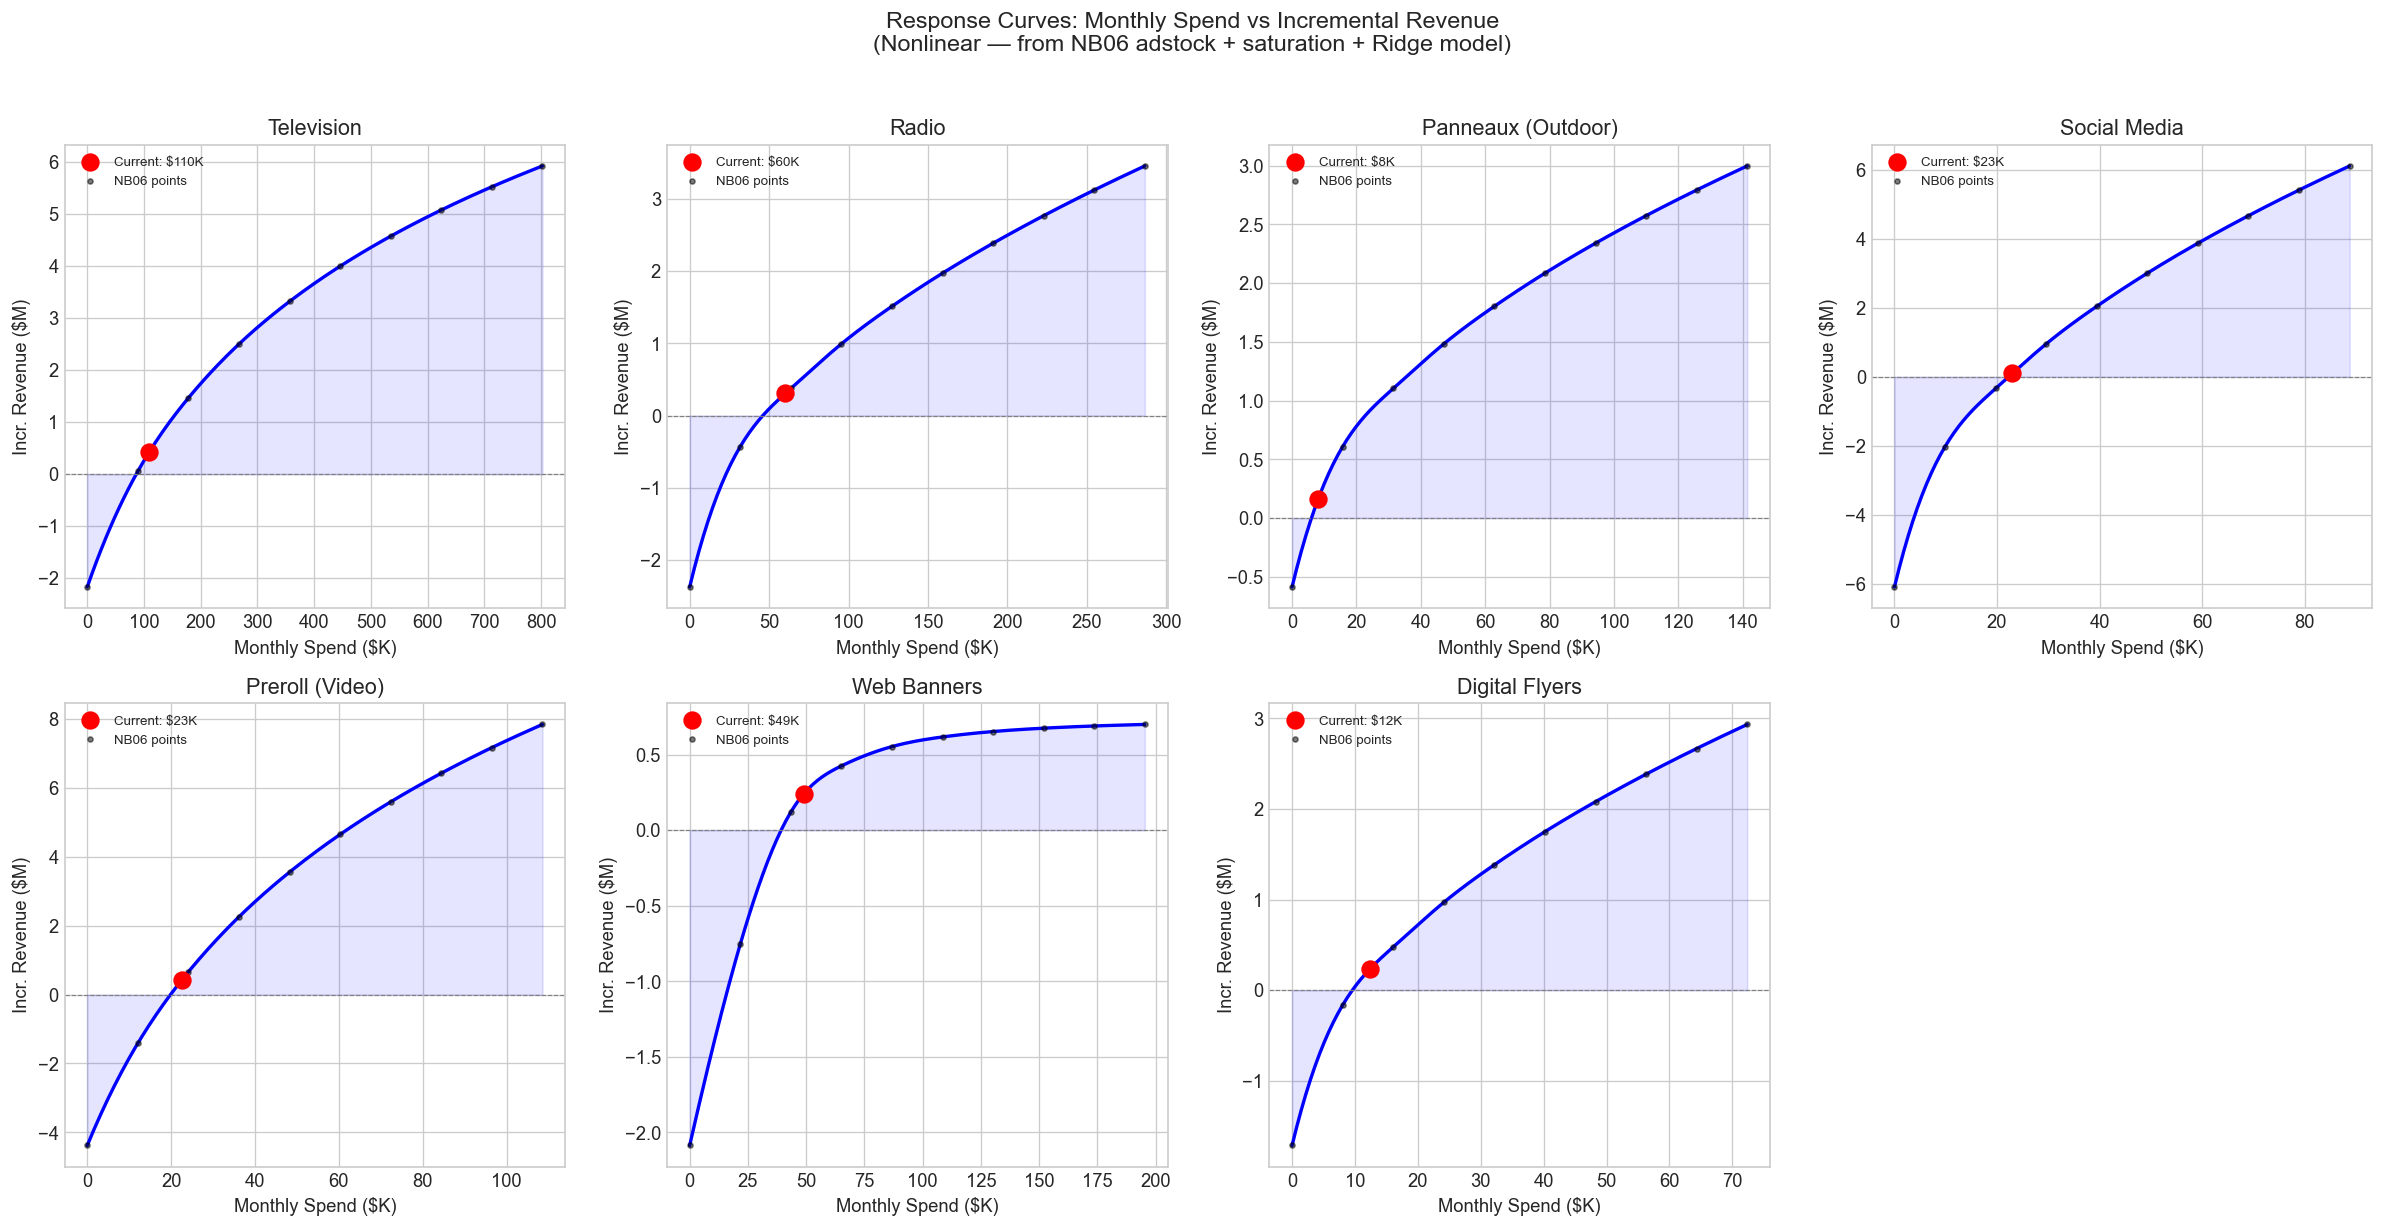

In [6]:
# ===================================================================
# 1-B  PLOT RESPONSE CURVES WITH CURRENT SPEND MARKERS
# ===================================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, ch in enumerate(CHANNELS):
    ax = axes[idx]
    label = CHANNEL_LABELS[ch]
    lo, hi = spend_bounds[ch]
    
    # Fine grid for smooth curve
    x_grid = np.linspace(lo, hi, 200)
    y_grid = response_funcs[ch](x_grid)
    
    ax.plot(x_grid / 1000, y_grid / 1e6, 'b-', linewidth=2)
    ax.fill_between(x_grid / 1000, y_grid / 1e6, alpha=0.1, color='blue')
    
    # Mark current spend
    curr = CURRENT_SPEND[ch]
    curr_rev = float(response_funcs[ch](curr))
    ax.plot(curr / 1000, curr_rev / 1e6, 'ro', markersize=10, zorder=5,
            label=f'Current: ${curr/1000:.0f}K')
    
    # Original data points
    ch_data = sat_total[sat_total['channel'] == ch]
    ax.plot(ch_data['spend'] / 1000, ch_data['incremental_revenue'] / 1e6,
            'k.', markersize=6, alpha=0.5, label='NB06 points')
    
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.7)
    ax.set_xlabel('Monthly Spend ($K)')
    ax.set_ylabel('Incr. Revenue ($M)')
    ax.set_title(label)
    ax.legend(fontsize=8)

# Hide last subplot
axes[-1].set_visible(False)

fig.suptitle('Response Curves: Monthly Spend vs Incremental Revenue\n'
             '(Nonlinear — from NB06 adstock + saturation + Ridge model)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'optimization_response_curves.png', dpi=150)
plt.show()

In [7]:
# ===================================================================
# 1-C  MARGINAL RESPONSE (FIRST DERIVATIVE) AT CURRENT SPEND
# ===================================================================
#
# The marginal response = slope of the curve at current spend.
# Channels with steep slopes at current spend have the most room to grow.
# Channels with flat slopes are saturated.

epsilon = 500  # $500 perturbation for numerical derivative

print('Marginal Response at Current Spend (numerical derivative):')
print('=' * 80)
print(f'{"Channel":25s} {"Current Spend":>14s} {"Marginal $/$$":>14s} {"Interpretation":>22s}')
print('-' * 80)

marginals_at_current = {}
for ch in CHANNELS:
    curr = CURRENT_SPEND[ch]
    rev_at_curr   = float(response_funcs[ch](curr))
    rev_at_plus   = float(response_funcs[ch](curr + epsilon))
    marginal = (rev_at_plus - rev_at_curr) / epsilon  # $/$ marginal
    marginals_at_current[ch] = marginal
    
    if marginal > 1:
        interp = 'High return - increase'
    elif marginal > 0:
        interp = 'Positive but < $1'
    else:
        interp = 'Negative - reduce'
    
    print(f'{CHANNEL_LABELS[ch]:25s} ${curr:>12,.0f}  ${marginal:>12.2f}  {interp:>22s}')

Marginal Response at Current Spend (numerical derivative):
Channel                    Current Spend  Marginal $/$$         Interpretation
--------------------------------------------------------------------------------
Television                $     109,693  $       17.47  High return - increase
Radio                     $      60,202  $       19.79  High return - increase
Panneaux (Outdoor)        $       8,125  $       71.92  High return - increase
Social Media              $      22,984  $      133.80  High return - increase
Preroll (Video)           $      22,574  $      152.13  High return - increase
Web Banners               $      48,949  $       17.88  High return - increase
Digital Flyers            $      12,404  $       71.24  High return - increase


---
## Section 2 — Budget Optimization

The optimizer finds the allocation that **maximizes total media-driven incremental revenue**
using the nonlinear response functions, subject to a total budget constraint.

Unlike a linear model (which would dump everything into one channel), the saturation curves
force diversification: each channel hits diminishing returns.

In [8]:
# ===================================================================
# 2-A  DEFINE NONLINEAR OBJECTIVE
# ===================================================================

def total_response(allocation, channels, response_funcs):
    """Sum of interpolated response across all channels."""
    return sum(float(response_funcs[ch](spend))
               for ch, spend in zip(channels, allocation))


def neg_total_response(allocation, channels, response_funcs):
    """Negative total response (for minimization)."""
    return -total_response(allocation, channels, response_funcs)


def optimize_budget(budget, channels, response_funcs, spend_bounds,
                    current_spend, min_spend_floor=500):
    """
    Find optimal allocation for a given total budget.
    
    Parameters
    ----------
    budget : float
        Total monthly media budget.
    min_spend_floor : float
        Minimum spend per channel (default $500).
    """
    n = len(channels)
    
    # Bounds: between min_spend_floor and curve max
    bounds = [(min_spend_floor, spend_bounds[ch][1]) for ch in channels]
    
    # Budget constraint: sum = budget
    constraint = {'type': 'eq', 'fun': lambda x: np.sum(x) - budget}
    
    # Start from proportional scaling of current allocation
    scale = budget / sum(current_spend[ch] for ch in channels)
    x0 = np.array([current_spend[ch] * scale for ch in channels])
    # Clip to bounds
    x0 = np.clip(x0, [b[0] for b in bounds], [b[1] for b in bounds])
    # Re-normalize to hit budget
    x0 = x0 * budget / x0.sum()
    
    result = minimize(
        neg_total_response,
        x0,
        args=(channels, response_funcs),
        method='SLSQP',
        bounds=bounds,
        constraints=[constraint],
        options={'maxiter': 2000, 'ftol': 1e-10}
    )
    
    allocation = {ch: max(result.x[i], min_spend_floor) for i, ch in enumerate(channels)}
    return allocation, result


print('Optimization functions defined.')
print(f'Budget constraint: total spend = ${TOTAL_MONTHLY_BUDGET:,.0f}/month')

Optimization functions defined.
Budget constraint: total spend = $284,931/month


In [9]:
# ===================================================================
# 2-B  RUN OPTIMIZATION (SAME BUDGET, OPTIMAL REALLOCATION)
# ===================================================================

optimal_alloc, opt_result = optimize_budget(
    TOTAL_MONTHLY_BUDGET, CHANNELS, response_funcs, spend_bounds, CURRENT_SPEND
)

print(f'Optimizer converged: {opt_result.success}')
print(f'Message: {opt_result.message}')
print()

# Compute responses
current_response = total_response(
    [CURRENT_SPEND[ch] for ch in CHANNELS], CHANNELS, response_funcs
)
optimal_response = total_response(
    [optimal_alloc[ch] for ch in CHANNELS], CHANNELS, response_funcs
)
lift = optimal_response - current_response
lift_pct = lift / abs(current_response) * 100 if current_response != 0 else 0

# Results table
print('=' * 100)
print('OPTIMAL BUDGET REALLOCATION (same total budget)')
print('=' * 100)
print(f'{"Channel":25s} {"Current":>12s} {"Cur %":>7s} {"Optimal":>12s} {"Opt %":>7s} '
      f'{"Change":>12s} {"Change%":>9s}')
print('-' * 100)

opt_rows = []
for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    opt = optimal_alloc[ch]
    change = opt - cur
    change_pct = change / cur * 100 if cur > 0 else 0
    cur_pct = cur / TOTAL_MONTHLY_BUDGET * 100
    opt_pct = opt / TOTAL_MONTHLY_BUDGET * 100
    
    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} {cur_pct:>6.1f}% ${opt:>10,.0f} {opt_pct:>6.1f}% '
          f'${change:>+10,.0f} {change_pct:>+8.1f}%')
    
    opt_rows.append({
        'channel': ch,
        'label': CHANNEL_LABELS[ch],
        'current_spend': cur,
        'current_pct': cur_pct,
        'optimal_spend': opt,
        'optimal_pct': opt_pct,
        'change': change,
        'change_pct': change_pct,
    })

print('-' * 100)
print(f'{"TOTAL":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f}         ${sum(optimal_alloc.values()):>10,.0f}')
print()
print(f'Current total media response:  ${current_response:>14,.0f}/month')
print(f'Optimal total media response:  ${optimal_response:>14,.0f}/month')
print(f'Incremental lift from realloc: ${lift:>+14,.0f}/month ({lift_pct:+.1f}%)')
print(f'Annualized lift:               ${lift * 12:>+14,.0f}/year')

opt_df = pd.DataFrame(opt_rows)

Optimizer converged: False
Message: Positive directional derivative for linesearch

OPTIMAL BUDGET REALLOCATION (same total budget)
Channel                        Current   Cur %      Optimal   Opt %       Change   Change%
----------------------------------------------------------------------------------------------------
Television                $   109,693   38.5% $       500    0.2% $  -109,193    -99.5%
Radio                     $    60,202   21.1% $    21,165    7.4% $   -39,037    -64.8%
Panneaux (Outdoor)        $     8,125    2.9% $    14,070    4.9% $    +5,945    +73.2%
Social Media              $    22,984    8.1% $    88,754   31.1% $   +65,770   +286.2%
Preroll (Video)           $    22,574    7.9% $   108,543   38.1% $   +85,969   +380.8%
Web Banners               $    48,949   17.2% $    23,590    8.3% $   -25,359    -51.8%
Digital Flyers            $    12,404    4.4% $    28,309    9.9% $   +15,905   +128.2%
------------------------------------------------------------

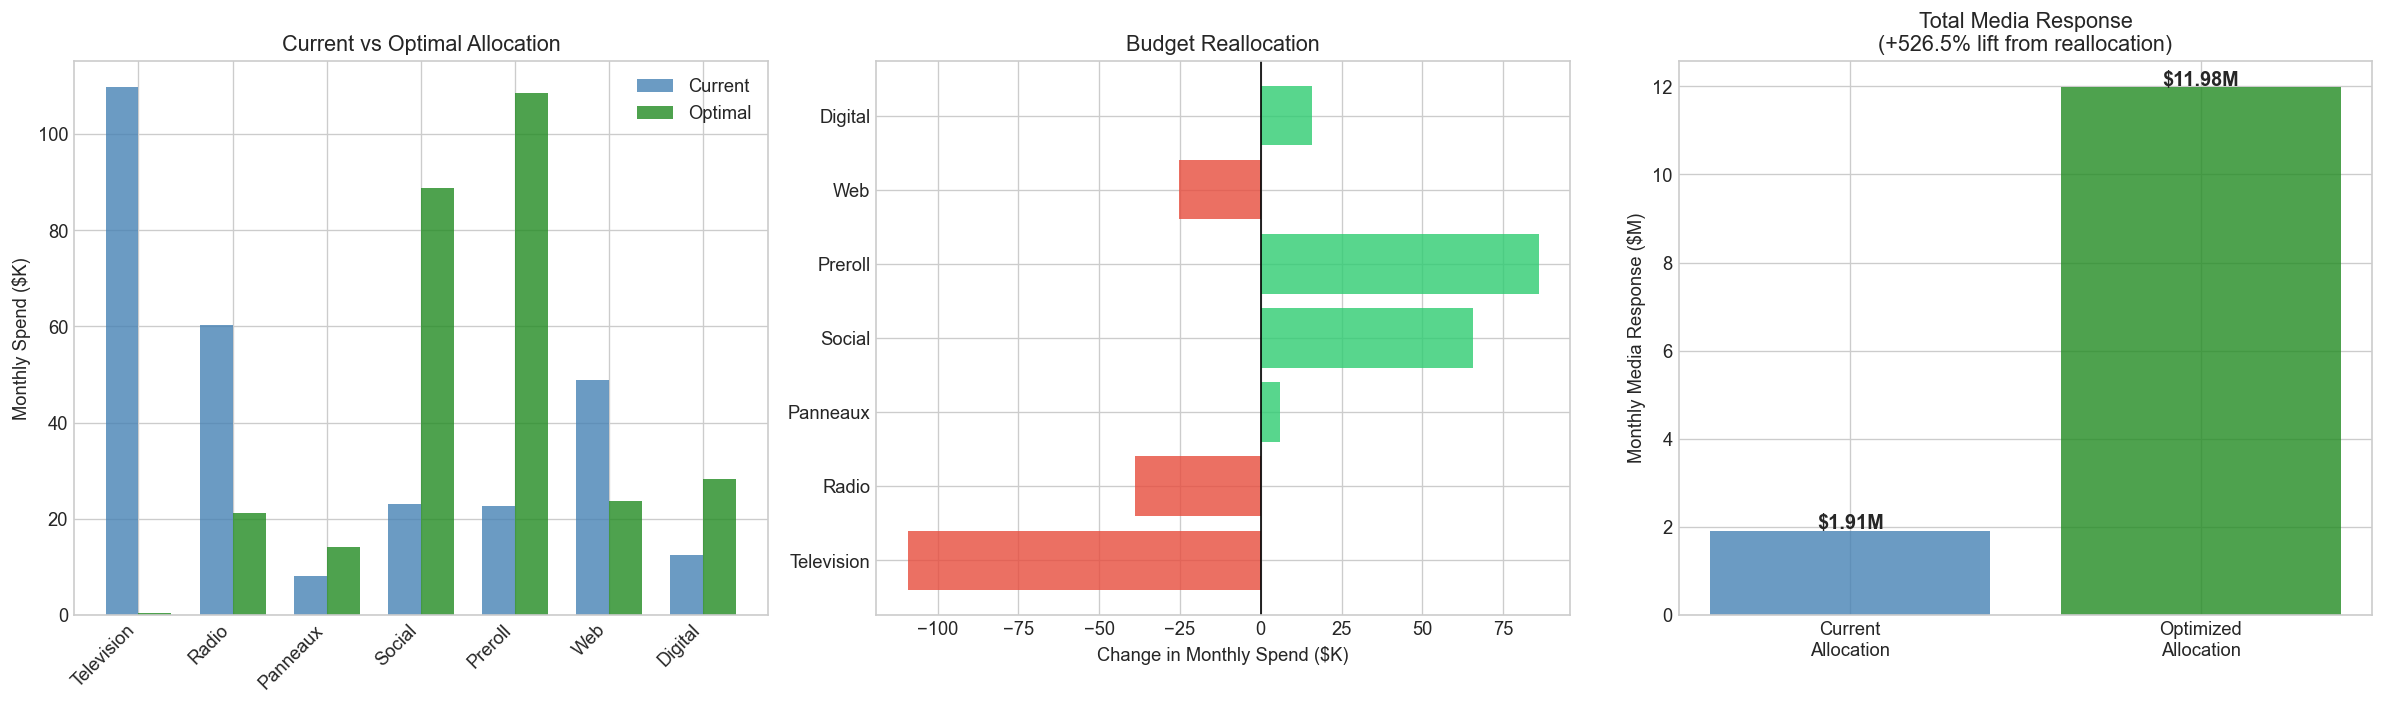

In [10]:
# ===================================================================
# 2-C  OPTIMIZATION VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Current vs Optimal Allocation (grouped bar)
ax = axes[0]
x = np.arange(len(CHANNELS))
width = 0.35
ax.bar(x - width/2, [CURRENT_SPEND[ch]/1000 for ch in CHANNELS], width,
       label='Current', color='steelblue', alpha=0.8)
ax.bar(x + width/2, [optimal_alloc[ch]/1000 for ch in CHANNELS], width,
       label='Optimal', color='forestgreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([CHANNEL_LABELS[ch].split()[0] for ch in CHANNELS],
                    rotation=45, ha='right')
ax.set_ylabel('Monthly Spend ($K)')
ax.set_title('Current vs Optimal Allocation')
ax.legend()

# 2. Change waterfall
ax = axes[1]
changes = [optimal_alloc[ch] - CURRENT_SPEND[ch] for ch in CHANNELS]
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in changes]
labels = [CHANNEL_LABELS[ch].split()[0] for ch in CHANNELS]
ax.barh(labels, [c/1000 for c in changes], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Change in Monthly Spend ($K)')
ax.set_title('Budget Reallocation')

# 3. Response comparison
ax = axes[2]
bars = ax.bar(['Current\nAllocation', 'Optimized\nAllocation'],
              [current_response / 1e6, optimal_response / 1e6],
              color=['steelblue', 'forestgreen'], alpha=0.8)
for bar, val in zip(bars, [current_response, optimal_response]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'${val/1e6:.2f}M', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Monthly Media Response ($M)')
ax.set_title(f'Total Media Response\n(+{lift_pct:.1f}% lift from reallocation)')

plt.tight_layout()
plt.savefig(figures_path / 'optimization_reallocation.png', dpi=150)
plt.show()

### 2-D  Business-Constrained Optimization

The unconstrained optimizer above recommends extreme shifts (e.g., TV to $500/mo) that violate
business constraints. Below we run a **constrained optimization** using the `BUSINESS_CONSTRAINTS`
configuration, which enforces:

1. **Channel floors/ceilings** — minimum effective spend thresholds + market capacity limits
2. **Production cost ratio** — only 85% of budget goes to media placement (constraint #10)
3. **Traditional/digital mix** — 35-65% traditional media (constraint #1 + media strategy narrative)

Constraints #12-13 (category visibility) and #15 (fitness overinvestment) are **visibility-level**
constraints that don't map directly to channel spend in our aggregate model. They are documented
for strategic context but not formally enforced in the optimizer.

In [ ]:
# ===================================================================
# 2-D  BUSINESS-CONSTRAINED OPTIMIZATION
# ===================================================================

def optimize_budget_constrained(budget, channels, response_funcs, spend_bounds,
                                current_spend, business_constraints):
    """
    Optimize budget allocation subject to business constraints.
    
    Additional constraints vs unconstrained version:
      - Per-channel min/max from business_constraints['channel_bounds']
      - Production ratio: effective budget = budget * media_pct_of_budget
      - Traditional/digital mix within target range
    """
    bc = business_constraints
    
    # Effective media budget after production cost deduction
    effective_budget = budget * bc['media_pct_of_budget']
    
    # Per-channel bounds: max of (business floor) and min of (business ceiling, curve max)
    bounds = []
    for ch in channels:
        biz_lo, biz_hi, _ = bc['channel_bounds'][ch]
        curve_hi = spend_bounds[ch][1]
        lo = biz_lo
        hi = min(biz_hi, curve_hi)
        bounds.append((lo, hi))
    
    # Constraints
    constraints = [
        # Sum = effective budget
        {'type': 'eq', 'fun': lambda x: np.sum(x) - effective_budget},
    ]
    
    # Traditional/digital mix constraints
    trad_indices = [i for i, ch in enumerate(channels) if ch in bc['traditional_channels']]
    trad_lo, trad_hi = bc['traditional_pct_range']
    
    # Traditional spend >= trad_lo * effective_budget
    constraints.append({
        'type': 'ineq',
        'fun': lambda x, idx=trad_indices, lo=trad_lo, b=effective_budget: (
            sum(x[i] for i in idx) - lo * b
        )
    })
    # Traditional spend <= trad_hi * effective_budget
    constraints.append({
        'type': 'ineq',
        'fun': lambda x, idx=trad_indices, hi=trad_hi, b=effective_budget: (
            hi * b - sum(x[i] for i in idx)
        )
    })
    
    # Starting point: proportional scaling of current allocation
    total_current = sum(current_spend[ch] for ch in channels)
    scale = effective_budget / total_current
    x0 = np.array([current_spend[ch] * scale for ch in channels])
    x0 = np.clip(x0, [b[0] for b in bounds], [b[1] for b in bounds])
    x0 = x0 * effective_budget / x0.sum()
    
    result = minimize(
        neg_total_response,
        x0,
        args=(channels, response_funcs),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 2000, 'ftol': 1e-10}
    )
    
    allocation = {ch: float(result.x[i]) for i, ch in enumerate(channels)}
    return allocation, result, effective_budget


# --- Run constrained optimization ---
constrained_alloc, constr_result, eff_budget = optimize_budget_constrained(
    TOTAL_MONTHLY_BUDGET, CHANNELS, response_funcs, spend_bounds,
    CURRENT_SPEND, BUSINESS_CONSTRAINTS
)

constrained_response = total_response(
    [constrained_alloc[ch] for ch in CHANNELS], CHANNELS, response_funcs
)
constr_lift = constrained_response - current_response
constr_lift_pct = constr_lift / abs(current_response) * 100 if current_response != 0 else 0

# --- Side-by-side comparison ---
print('=' * 120)
print('COMPARISON: UNCONSTRAINED vs BUSINESS-CONSTRAINED OPTIMIZATION')
print('=' * 120)
print(f'{"":25s} {"Current":>12s} {"Unconstrained":>14s} {"Constrained":>14s} {"Constr vs Curr":>15s}')
print('-' * 120)

for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    unc = optimal_alloc[ch]
    con = constrained_alloc[ch]
    con_chg = (con - cur) / cur * 100 if cur > 0 else 0
    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} ${unc:>12,.0f} ${con:>12,.0f} {con_chg:>+13.1f}%')

print('-' * 120)
unc_total = sum(optimal_alloc.values())
con_total = sum(constrained_alloc.values())
print(f'{"TOTAL MEDIA SPEND":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f} ${unc_total:>12,.0f} ${con_total:>12,.0f}')
print(f'{"(Production cost)":25s} {"":>12s} {"":>14s} ${TOTAL_MONTHLY_BUDGET - eff_budget:>12,.0f}')
print(f'{"(Full budget)":25s} {"":>12s} {"":>14s} ${TOTAL_MONTHLY_BUDGET:>12,.0f}')
print()

# Traditional/digital split check
trad_con = sum(constrained_alloc[ch] for ch in BUSINESS_CONSTRAINTS['traditional_channels'])
trad_pct_con = trad_con / con_total * 100
print(f'Traditional/Digital split (constrained): {trad_pct_con:.1f}% / {100-trad_pct_con:.1f}%')
trad_unc = sum(optimal_alloc[ch] for ch in BUSINESS_CONSTRAINTS['traditional_channels'])
trad_pct_unc = trad_unc / unc_total * 100
print(f'Traditional/Digital split (unconstrained): {trad_pct_unc:.1f}% / {100-trad_pct_unc:.1f}%')
print()

print(f'Optimizer converged: {constr_result.success}')
print(f'Message: {constr_result.message}')
print()
print('RESPONSE COMPARISON:')
print(f'  Current allocation response:       ${current_response:>14,.0f}/month')
print(f'  Unconstrained optimal response:    ${optimal_response:>14,.0f}/month  (+{lift_pct:.1f}%)')
print(f'  Constrained optimal response:      ${constrained_response:>14,.0f}/month  (+{constr_lift_pct:.1f}%)')
print(f'  Cost of constraints:               ${optimal_response - constrained_response:>14,.0f}/month')
print(f'    (theoretical revenue given up for business realism)')
print()
print('NOTE: The constrained optimizer uses 85% of the total budget for media')
print(f'      placement (${eff_budget:,.0f}/mo), reserving 15% for production costs.')

---
## Section 3 — Scenario Analysis

The use case objective asks: *"Can we achieve equivalent performance with a 10–15% budget reduction?"*

We test multiple scenarios, each with its own optimized allocation.

In [11]:
# ===================================================================
# 3-A  RUN SCENARIOS
# ===================================================================

scenarios = {
    'Cut 15%':       0.85,
    'Cut 10%':       0.90,
    'Cut 5%':        0.95,
    'Current':       1.00,
    'Increase 10%':  1.10,
    'Increase 20%':  1.20,
}

scenario_results = []

for name, multiplier in scenarios.items():
    budget = TOTAL_MONTHLY_BUDGET * multiplier
    
    # Optimize for this budget level
    alloc, res = optimize_budget(
        budget, CHANNELS, response_funcs, spend_bounds, CURRENT_SPEND
    )
    
    opt_resp = total_response([alloc[ch] for ch in CHANNELS], CHANNELS, response_funcs)
    
    scenario_results.append({
        'scenario': name,
        'multiplier': multiplier,
        'budget': budget,
        'optimized_response': opt_resp,
        'converged': res.success,
        'allocation': alloc,
    })

# Also compute current allocation response (no optimization) at each budget
# to compare "optimized at lower budget" vs "current allocation at full budget"

scenario_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'allocation'} for r in scenario_results
])

# Add comparison to current (un-optimized) response
scenario_df['vs_current'] = scenario_df['optimized_response'] - current_response
scenario_df['vs_current_pct'] = scenario_df['vs_current'] / abs(current_response) * 100

print('Scenario Analysis: Optimized Allocation at Different Budget Levels')
print('=' * 100)
print(f'{"Scenario":>15s} {"Budget/mo":>12s} {"Opt Response/mo":>16s} '
      f'{"vs Current":>14s} {"vs Current %":>13s} {"Conv?":>6s}')
print('-' * 100)
for _, row in scenario_df.iterrows():
    print(f'{row["scenario"]:>15s} ${row["budget"]:>10,.0f} ${row["optimized_response"]:>14,.0f} '
          f'${row["vs_current"]:>+12,.0f} {row["vs_current_pct"]:>+12.1f}% '
          f'{"Yes" if row["converged"] else "No":>6s}')

Scenario Analysis: Optimized Allocation at Different Budget Levels
       Scenario    Budget/mo  Opt Response/mo     vs Current  vs Current %  Conv?
----------------------------------------------------------------------------------------------------
        Cut 15% $   242,191 $     9,574,251 $  +7,662,677       +400.9%    Yes
        Cut 10% $   256,438 $    10,417,498 $  +8,505,924       +445.0%    Yes
         Cut 5% $   270,684 $    11,218,616 $  +9,307,042       +486.9%    Yes
        Current $   284,931 $    11,976,256 $ +10,064,682       +526.5%     No
   Increase 10% $   313,424 $    13,307,748 $ +11,396,174       +596.2%    Yes
   Increase 20% $   341,917 $    14,431,619 $ +12,520,045       +655.0%     No


In [12]:
# ===================================================================
# 3-B  KEY QUESTION: CAN WE CUT 10-15% AND MATCH CURRENT PERFORMANCE?
# ===================================================================

print('KEY QUESTION: Can we reduce the budget by 10-15% with optimized allocation')
print('             and still match current (un-optimized) performance?')
print('=' * 80)
print()
print(f'Current allocation response:  ${current_response:>14,.0f}/month')
print()

for r in scenario_results:
    if r['multiplier'] in [0.85, 0.90, 0.95]:
        diff = r['optimized_response'] - current_response
        pct = diff / abs(current_response) * 100
        budget_saved = TOTAL_MONTHLY_BUDGET - r['budget']
        status = 'MATCHES or EXCEEDS' if diff >= 0 else 'FALLS SHORT by'
        
        print(f'{r["scenario"]:>10s} budget (${r["budget"]:,.0f}/mo):')
        print(f'  Optimized response: ${r["optimized_response"]:>14,.0f}/month')
        if diff >= 0:
            print(f'  --> {status} current performance (+${diff:,.0f})')
        else:
            print(f'  --> {status} ${abs(diff):,.0f} ({pct:.1f}%)')
        print(f'  Budget saved: ${budget_saved:,.0f}/month (${budget_saved*12:,.0f}/year)')
        print()

KEY QUESTION: Can we reduce the budget by 10-15% with optimized allocation
             and still match current (un-optimized) performance?

Current allocation response:  $     1,911,574/month

   Cut 15% budget ($242,191/mo):
  Optimized response: $     9,574,251/month
  --> MATCHES or EXCEEDS current performance (+$7,662,677)
  Budget saved: $42,740/month ($512,875/year)

   Cut 10% budget ($256,438/mo):
  Optimized response: $    10,417,498/month
  --> MATCHES or EXCEEDS current performance (+$8,505,924)
  Budget saved: $28,493/month ($341,917/year)

    Cut 5% budget ($270,684/mo):
  Optimized response: $    11,218,616/month
  --> MATCHES or EXCEEDS current performance (+$9,307,042)
  Budget saved: $14,247/month ($170,958/year)



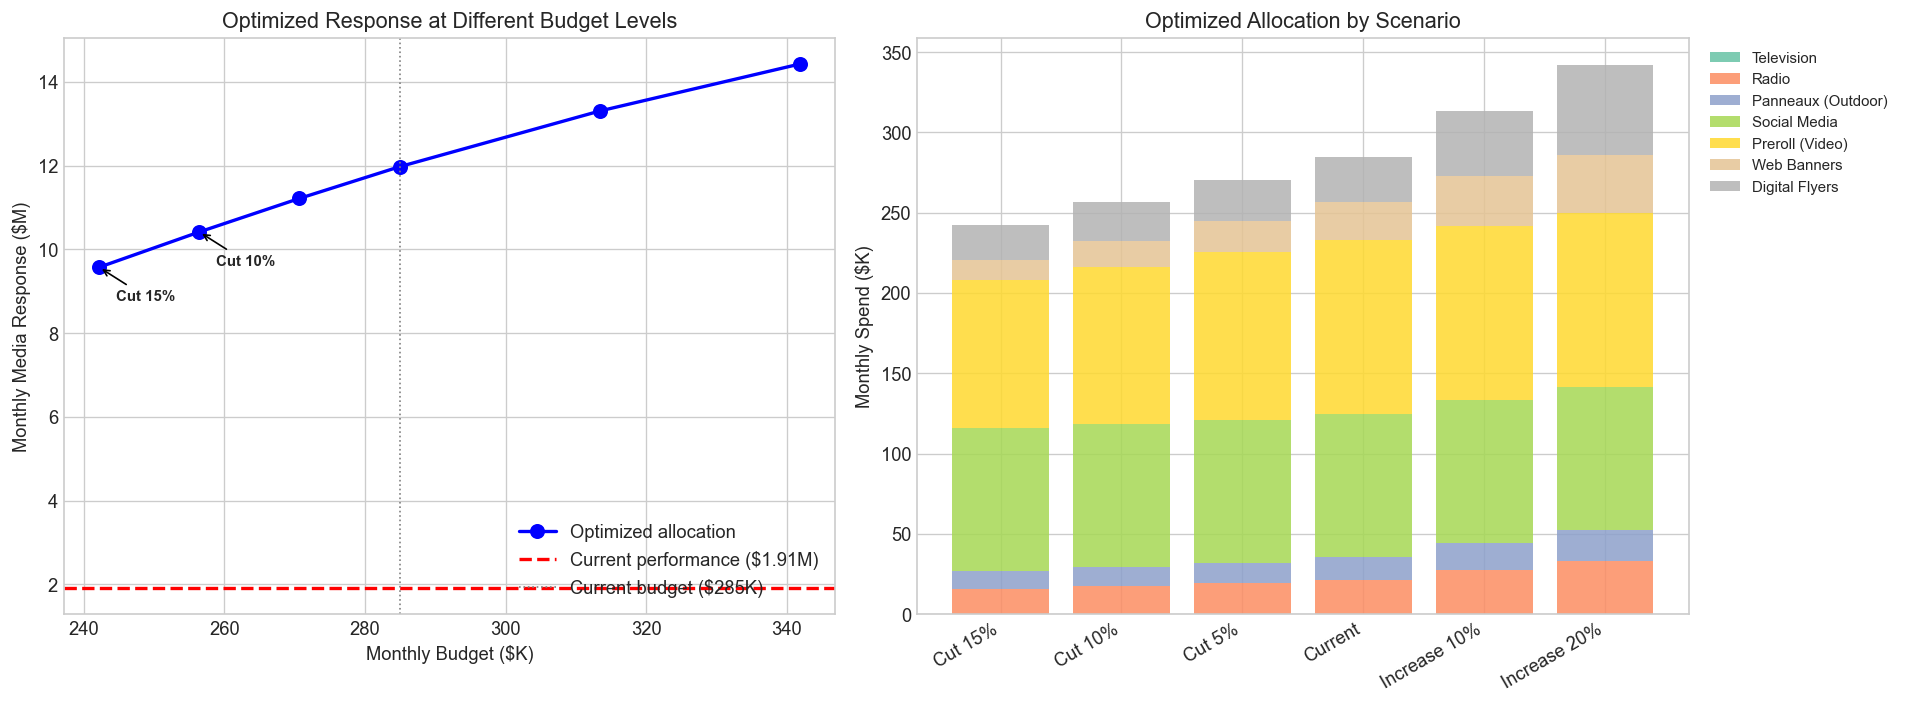

In [13]:
# ===================================================================
# 3-C  SCENARIO VISUALIZATION
# ===================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Response at each budget level
ax = axes[0]
ax.plot(scenario_df['budget'] / 1000, scenario_df['optimized_response'] / 1e6,
        'b-o', linewidth=2, markersize=8, label='Optimized allocation')
ax.axhline(current_response / 1e6, color='red', linestyle='--', linewidth=2,
           label=f'Current performance (${current_response/1e6:.2f}M)')
ax.axvline(TOTAL_MONTHLY_BUDGET / 1000, color='grey', linestyle=':', linewidth=1,
           label=f'Current budget (${TOTAL_MONTHLY_BUDGET/1000:.0f}K)')

# Mark the budget-cut scenarios
for r in scenario_results:
    if r['multiplier'] in [0.85, 0.90]:
        ax.annotate(r['scenario'],
                    xy=(r['budget']/1000, r['optimized_response']/1e6),
                    xytext=(10, -20), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Monthly Budget ($K)')
ax.set_ylabel('Monthly Media Response ($M)')
ax.set_title('Optimized Response at Different Budget Levels')
ax.legend(loc='lower right')

# 2. Allocation breakdown per scenario
ax = axes[1]
bottom = np.zeros(len(scenario_results))
scenario_names = [r['scenario'] for r in scenario_results]
colors = plt.cm.Set2(np.linspace(0, 1, len(CHANNELS)))

for i, ch in enumerate(CHANNELS):
    values = [r['allocation'][ch] / 1000 for r in scenario_results]
    ax.bar(scenario_names, values, bottom=bottom, label=CHANNEL_LABELS[ch],
           color=colors[i], alpha=0.85)
    bottom += values

ax.set_ylabel('Monthly Spend ($K)')
ax.set_title('Optimized Allocation by Scenario')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(figures_path / 'optimization_scenarios.png', dpi=150)
plt.show()

In [14]:
# ===================================================================
# 3-D  DETAILED ALLOCATION TABLE FOR 10% CUT SCENARIO
# ===================================================================

# Find the -10% scenario
cut10 = [r for r in scenario_results if r['multiplier'] == 0.90][0]

print('Detailed Allocation: 10% Budget Cut with Optimal Reallocation')
print('=' * 100)
print(f'{"Channel":25s} {"Current":>12s} {"Cut 10% Opt":>12s} {"Change":>12s} {"Change%":>9s}')
print('-' * 100)

for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    new = cut10['allocation'][ch]
    change = new - cur
    change_pct = change / cur * 100 if cur > 0 else 0
    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} ${new:>10,.0f} ${change:>+10,.0f} {change_pct:>+8.1f}%')

print('-' * 100)
print(f'{"TOTAL":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f} ${cut10["budget"]:>10,.0f}')
print(f'\nBudget saved: ${TOTAL_MONTHLY_BUDGET - cut10["budget"]:,.0f}/month '
      f'(${(TOTAL_MONTHLY_BUDGET - cut10["budget"])*12:,.0f}/year)')

Detailed Allocation: 10% Budget Cut with Optimal Reallocation
Channel                        Current  Cut 10% Opt       Change   Change%
----------------------------------------------------------------------------------------------------
Television                $   109,693 $       500 $  -109,193    -99.5%
Radio                     $    60,202 $    16,984 $   -43,219    -71.8%
Panneaux (Outdoor)        $     8,125 $    12,059 $    +3,934    +48.4%
Social Media              $    22,984 $    88,754 $   +65,770   +286.2%
Preroll (Video)           $    22,574 $    97,985 $   +75,412   +334.1%
Web Banners               $    48,949 $    16,343 $   -32,606    -66.6%
Digital Flyers            $    12,404 $    23,812 $   +11,408    +92.0%
----------------------------------------------------------------------------------------------------
TOTAL                     $   284,931 $   256,438

Budget saved: $28,493/month ($341,917/year)


---
## Section 4 — Executive Summary & Recommendations

In [15]:
# ===================================================================
# 4-A  EXECUTIVE SUMMARY TABLE
# ===================================================================

print('=' * 110)
print('EXECUTIVE SUMMARY: MEDIA BUDGET OPTIMIZATION')
print('=' * 110)
print()

# Channel-level recommendations
print(f'{"Channel":25s} {"Current/mo":>12s} {"Recommended/mo":>14s} '
      f'{"Change":>10s} {"ROAS":>8s} {"CI sig?":>8s} {"Action":>15s}')
print('-' * 110)

summary_rows = []
for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    rec = optimal_alloc[ch]
    change_pct = (rec - cur) / cur * 100 if cur > 0 else 0
    roas = eff_total.loc[ch, 'roas']
    ci_lo = eff_total.loc[ch, 'marginal_ci_lo']
    sig = 'Yes' if ci_lo > 0 else 'No'
    
    if change_pct > 10:
        action = 'INCREASE'
    elif change_pct < -10:
        action = 'DECREASE'
    else:
        action = 'MAINTAIN'
    
    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} ${rec:>12,.0f} '
          f'{change_pct:>+9.0f}% {roas:>7.1f} {sig:>8s} {action:>15s}')
    
    summary_rows.append({
        'channel': CHANNEL_LABELS[ch],
        'current_spend_monthly': cur,
        'recommended_spend_monthly': rec,
        'change_pct': change_pct,
        'roas': roas,
        'statistically_significant': sig,
        'action': action,
    })

print('-' * 110)
print(f'{"TOTAL":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f} ${sum(optimal_alloc.values()):>12,.0f}')

summary_df = pd.DataFrame(summary_rows)

EXECUTIVE SUMMARY: MEDIA BUDGET OPTIMIZATION

Channel                     Current/mo Recommended/mo     Change     ROAS  CI sig?          Action
--------------------------------------------------------------------------------------------------------------
Television                $   109,693 $         500      -100%    16.8      Yes        DECREASE
Radio                     $    60,202 $      21,165       -65%    23.3      Yes        DECREASE
Panneaux (Outdoor)        $     8,125 $      14,070       +73%    88.1       No        INCREASE
Social Media              $    22,984 $      88,754      +286%   143.1      Yes        INCREASE
Preroll (Video)           $    22,574 $     108,543      +381%   153.4      Yes        INCREASE
Web Banners               $    48,949 $      23,590       -52%    29.1      Yes        DECREASE
Digital Flyers            $    12,404 $      28,309      +128%    89.2      Yes        INCREASE
------------------------------------------------------------------------

In [16]:
# ===================================================================
# 4-B  KEY METRICS
# ===================================================================

print()
print('KEY METRICS')
print('=' * 70)
print()
print('DATA:')
print(f'  Observations:                {len(df)} months (FY2023-FY2025)')
print(f'  Media Channels:              {len(CHANNELS)}')
print(f'  Model R\u00b2 (in-sample):        {model_params["ridge_r2"]["Total Revenue"]:.3f}')
print(f'  Model R\u00b2 (LOOCV):            {model_params["ridge_r2_cv"]["Total Revenue"]:.3f}')
print()
print('FINANCIAL:')
print(f'  Total Revenue (3Y):          ${total_revenue_3y:>14,.0f}')
print(f'  Total Media Spend (3Y):      ${total_spend_3y:>14,.0f}')
print(f'  Monthly Budget:              ${TOTAL_MONTHLY_BUDGET:>14,.0f}')
print()
print('OPTIMIZATION RESULTS (same budget, reallocated):')
print(f'  Current media response:      ${current_response:>14,.0f}/month')
print(f'  Optimized media response:    ${optimal_response:>14,.0f}/month')
print(f'  Lift from reallocation:      ${lift:>+14,.0f}/month ({lift_pct:+.1f}%)')
print(f'  Annualized lift:             ${lift * 12:>+14,.0f}/year')
print()
print('BUDGET REDUCTION ANALYSIS:')
for r in scenario_results:
    if r['multiplier'] in [0.85, 0.90]:
        diff = r['optimized_response'] - current_response
        saved = (TOTAL_MONTHLY_BUDGET - r['budget']) * 12
        result_str = 'above current' if diff >= 0 else f'below current by ${abs(diff):,.0f}'
        print(f'  {r["scenario"]:>8s}: optimized response {result_str} '
              f'(saves ${saved:,.0f}/year)')
print()
print('LIMITATIONS:')
print('  - Based on 36 monthly observations (small sample)')
print('  - Only Preroll has statistically significant positive ROAS (90% CI)')
print('  - Saturation curve extrapolation beyond observed spend ranges is uncertain')
print('  - Recommendations should be validated with controlled budget experiments')


KEY METRICS

DATA:
  Observations:                36 months (FY2023-FY2025)
  Media Channels:              7
  Model R² (in-sample):        0.916
  Model R² (LOOCV):            0.862

FINANCIAL:
  Total Revenue (3Y):          $   512,411,602
  Total Media Spend (3Y):      $    10,257,505
  Monthly Budget:              $       284,931

OPTIMIZATION RESULTS (same budget, reallocated):
  Current media response:      $     1,911,574/month
  Optimized media response:    $    11,976,256/month
  Lift from reallocation:      $   +10,064,682/month (+526.5%)
  Annualized lift:             $  +120,776,182/year

BUDGET REDUCTION ANALYSIS:
   Cut 15%: optimized response above current (saves $512,875/year)
   Cut 10%: optimized response above current (saves $341,917/year)

LIMITATIONS:
  - Based on 36 monthly observations (small sample)
  - Only Preroll has statistically significant positive ROAS (90% CI)
  - Saturation curve extrapolation beyond observed spend ranges is uncertain
  - Recommendatio

In [17]:
# ===================================================================
# 4-C  SAVE OUTPUTS
# ===================================================================

# 1. Optimization results
opt_df.to_csv(processed_path / 'mmm_optimization_results.csv', index=False)
print(f'Saved: mmm_optimization_results.csv')

# 2. Scenario analysis
scenario_df.to_csv(processed_path / 'mmm_scenario_analysis.csv', index=False)
print(f'Saved: mmm_scenario_analysis.csv')

# 3. Executive summary
summary_df.to_csv(processed_path / 'mmm_executive_summary.csv', index=False)
print(f'Saved: mmm_executive_summary.csv')

# 4. Combined output JSON
mmm_output = {
    'source_notebook': 'NB07_budget_optimization',
    'model_source': 'NB06_causal_inference',
    'created': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_summary': {
        'n_months': len(df),
        'total_revenue_3y': float(total_revenue_3y),
        'total_spend_3y': float(total_spend_3y),
        'monthly_budget': float(TOTAL_MONTHLY_BUDGET),
    },
    'model_performance': {
        'r2': model_params['ridge_r2']['Total Revenue'],
        'r2_cv': model_params['ridge_r2_cv']['Total Revenue'],
    },
    'optimization': {
        'current_response': float(current_response),
        'optimal_response': float(optimal_response),
        'lift_pct': float(lift_pct),
        'current_allocation': {ch: float(v) for ch, v in CURRENT_SPEND.items()},
        'optimal_allocation': {ch: float(v) for ch, v in optimal_alloc.items()},
    },
    'scenarios': [
        {
            'name': r['scenario'],
            'budget': float(r['budget']),
            'optimized_response': float(r['optimized_response']),
            'vs_current': float(r['optimized_response'] - current_response),
        }
        for r in scenario_results
    ],
}

with open(processed_path / 'mmm_final_output.json', 'w') as f:
    json.dump(mmm_output, f, indent=2)
print(f'Saved: mmm_final_output.json')

Saved: mmm_optimization_results.csv
Saved: mmm_scenario_analysis.csv
Saved: mmm_executive_summary.csv
Saved: mmm_final_output.json


In [18]:
# ===================================================================
# 4-D  FINAL SUMMARY
# ===================================================================

print()
print('=' * 80)
print('  NOTEBOOK 07 -- BUDGET OPTIMIZATION & SCENARIO ANALYSIS: COMPLETE')
print('=' * 80)
print()
print('PIPELINE:')
print('  NB06 (Causal Inference)  -->  Fit Ridge model, validate, estimate ROAS')
print('  NB07 (This notebook)     -->  Optimize allocation, test scenarios')
print()
print('OUTPUT FILES:')
print('  data/processed/mmm_optimization_results.csv')
print('  data/processed/mmm_scenario_analysis.csv')
print('  data/processed/mmm_executive_summary.csv')
print('  data/processed/mmm_final_output.json')
print()
print('FIGURES:')
for f in sorted(figures_path.glob('optimization_*.png')):
    print(f'  reports/figures/{f.name}')


  NOTEBOOK 07 -- BUDGET OPTIMIZATION & SCENARIO ANALYSIS: COMPLETE

PIPELINE:
  NB06 (Causal Inference)  -->  Fit Ridge model, validate, estimate ROAS
  NB07 (This notebook)     -->  Optimize allocation, test scenarios

OUTPUT FILES:
  data/processed/mmm_optimization_results.csv
  data/processed/mmm_scenario_analysis.csv
  data/processed/mmm_executive_summary.csv
  data/processed/mmm_final_output.json

FIGURES:
  reports/figures/optimization_reallocation.png
  reports/figures/optimization_response_curves.png
  reports/figures/optimization_scenarios.png
